# EDA: Did Remote Work Permanently Reshape Urban Housing Markets?

**Datasets**
- **ACS B08301** – Means of Transportation to Work (county-level, 2015–2024, no 2020)
- **Zillow ZHVI** – Metro-area home value index, monthly 2000–2026

**Research question**: Did the COVID-driven spike in remote work permanently shift housing demand away from dense urban metros toward suburban/lower-cost markets?

## 1  Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import glob, warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (13, 5)
plt.rcParams['figure.dpi'] = 110
sns.set_theme(style='whitegrid', palette='muted')

DATA_DIR = '.'
ZILLOW_PATH = './data/Metro_zhvi_uc_sfrcondo_tier_0.33_0.67_sm_sa_month.csv'

## 2  ACS Commuting Data

### 2.1  Load & clean

In [2]:
ACS_COLS = {
    'B08301_001E': 'total_workers',
    'B08301_002E': 'car_truck_van',
    'B08301_003E': 'drove_alone',
    'B08301_004E': 'carpooled',
    'B08301_010E': 'public_transit',
    'B08301_017E': 'motorcycle',
    'B08301_018E': 'bicycle',
    'B08301_019E': 'walked',
    'B08301_020E': 'other_means',
    'B08301_021E': 'worked_at_home',
}

frames = []
for fp in sorted(glob.glob(f'{DATA_DIR}/ACSDT1Y*.B08301-Data.csv')):
    year = int(fp.split('ACSDT1Y')[1][:4])
    df = pd.read_csv(fp, header=0, skiprows=[1])
    df = df[['GEO_ID', 'NAME'] + list(ACS_COLS)].rename(columns=ACS_COLS)
    df['year'] = year
    df['fips'] = df['GEO_ID'].str.extract(r'US(\d+)$')[0]
    df['state'] = df['NAME'].str.extract(r',\s*(.+)$')[0].str.strip()
    frames.append(df)

acs = pd.concat(frames, ignore_index=True)
acs.replace('null', np.nan, inplace=True)
num_cols = list(ACS_COLS.values())
acs[num_cols] = acs[num_cols].apply(pd.to_numeric, errors='coerce')

# WFH share (0–100 %)
acs['wfh_pct'] = acs['worked_at_home'] / acs['total_workers'] * 100
acs['drove_alone_pct'] = acs['drove_alone'] / acs['total_workers'] * 100
acs['public_transit_pct'] = acs['public_transit'] / acs['total_workers'] * 100

print(f'Combined ACS shape: {acs.shape}')
print(f'Years: {sorted(acs.year.unique())}')
print(f'Counties per year (median): {acs.groupby("year").size().median():.0f}')
acs.head(3)

Combined ACS shape: (7580, 18)
Years: [np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
Counties per year (median): 840


,GEO_ID,NAME,total_workers,car_truck_van,drove_alone,carpooled,public_transit,motorcycle,bicycle,walked,other_means,worked_at_home,year,fips,state,wfh_pct,drove_alone_pct,public_transit_pct
0,0500000US01003,"Baldwin County, Alabama",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2015,01003,Alabama,NaN,NaN,NaN
1,0500000US01015,"Calhoun County, Alabama",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2015,01015,Alabama,NaN,NaN,NaN
2,0500000US01043,"Cullman County, Alabama",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2015,01043,Alabama,NaN,NaN,NaN


### 2.2  Missing data

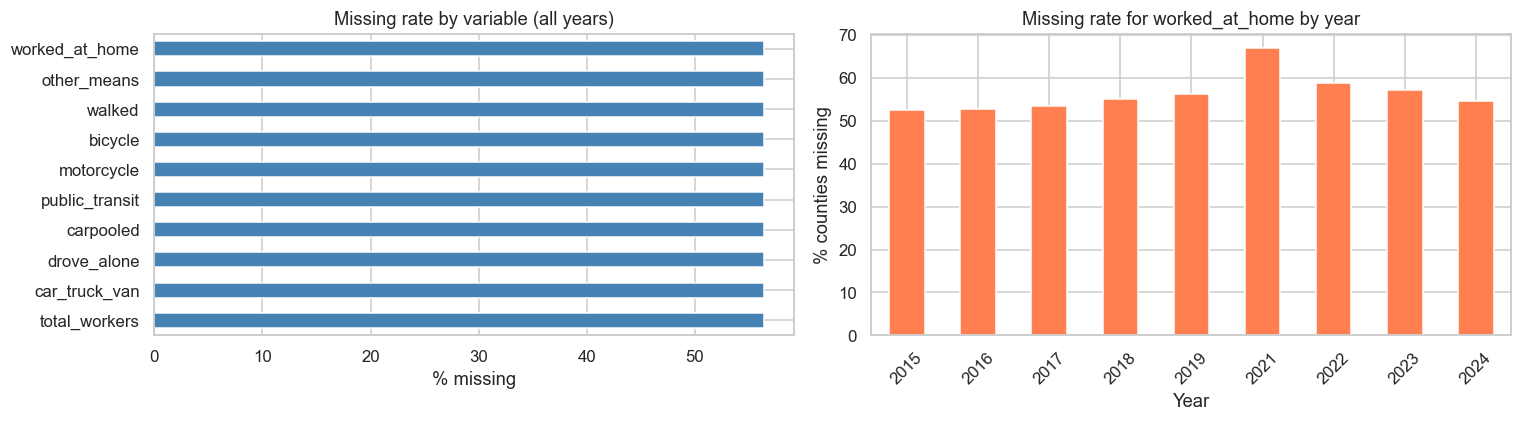

Note: ACS suppresses estimates for small counties; no 2020 due to COVID survey disruption.


In [3]:
miss = acs[num_cols].isna().mean().sort_values(ascending=False) * 100
miss_by_year = acs.groupby('year')['worked_at_home'].apply(lambda x: x.isna().mean() * 100)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

miss.plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_xlabel('% missing')
axes[0].set_title('Missing rate by variable (all years)')

miss_by_year.plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('% counties missing')
axes[1].set_title('Missing rate for worked_at_home by year')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print('Note: ACS suppresses estimates for small counties; no 2020 due to COVID survey disruption.')

### 2.3  Descriptive statistics

In [4]:
acs[num_cols + ['wfh_pct', 'drove_alone_pct', 'public_transit_pct']].describe().round(1)

,total_workers,car_truck_van,drove_alone,carpooled,public_transit,motorcycle,bicycle,walked,other_means,worked_at_home,wfh_pct,drove_alone_pct,public_transit_pct
count,3305.0,3305.0,3305.0,3305.0,3305.0,3305.0,3305.0,3305.0,3305.0,3305.0,3305.0,3305.0,3305.0
mean,296263.0,233388.8,207543.5,25845.3,17196.0,456.2,1807.5,7970.9,3163.3,31417.4,9.4,73.7,3.5
std,389203.9,302934.7,267004.3,36582.1,61754.0,952.3,3826.6,15699.0,5227.0,55095.0,6.5,10.4,7.1
min,27389.0,24517.0,22265.0,1853.0,0.0,0.0,0.0,0.0,0.0,445.0,1.0,5.2,0.0
25%,101540.0,87874.0,78848.0,9126.0,848.0,74.0,257.0,2034.0,777.0,6395.0,4.6,69.9,0.7
50%,180306.0,150516.0,134836.0,15823.0,2414.0,208.0,635.0,3822.0,1653.0,14244.0,6.9,76.0,1.4
75%,357401.0,273825.0,244711.0,29292.0,8839.0,465.0,1555.0,7632.0,3527.0,34052.0,13.1,80.3,3.1
max,4931598.0,4103368.0,3643466.0,477000.0,746219.0,13341.0,44983.0,198275.0,70295.0,946616.0,48.8,90.4,62.0


### 2.4  National WFH trend

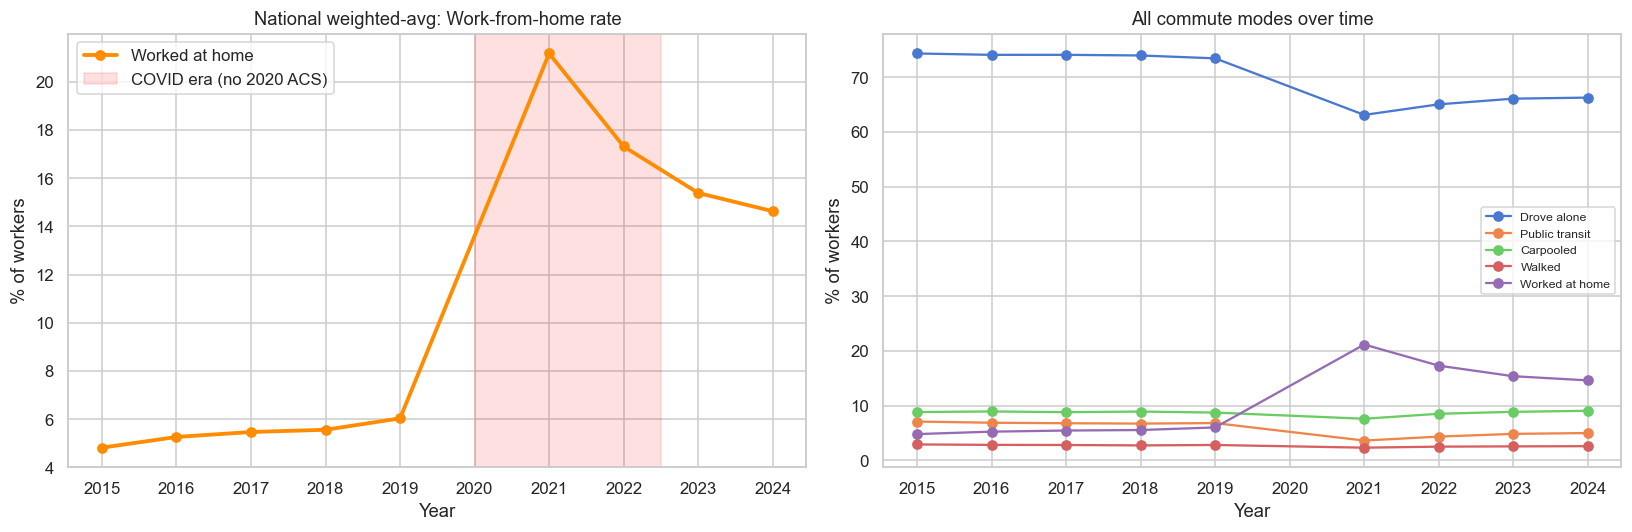

WFH change 2019→2021 (pp): 15.14
WFH change 2021→2024 (pp): -6.55


In [5]:
# Weighted national average WFH %
nat = (
    acs.dropna(subset=['worked_at_home', 'total_workers'])
    .groupby('year')
    .apply(lambda g: pd.Series({
        'wfh_pct': g['worked_at_home'].sum() / g['total_workers'].sum() * 100,
        'drove_alone_pct': g['drove_alone'].sum() / g['total_workers'].sum() * 100,
        'public_transit_pct': g['public_transit'].sum() / g['total_workers'].sum() * 100,
        'carpooled_pct': g['carpooled'].sum() / g['total_workers'].sum() * 100,
        'walked_pct': g['walked'].sum() / g['total_workers'].sum() * 100,
    }), include_groups=False)
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(nat['year'], nat['wfh_pct'], marker='o', color='darkorange', lw=2.5, label='Worked at home')
axes[0].axvspan(2020, 2022.5, alpha=0.12, color='red', label='COVID era (no 2020 ACS)')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('% of workers')
axes[0].set_title('National weighted-avg: Work-from-home rate')
axes[0].legend()
axes[0].xaxis.set_major_locator(mticker.MultipleLocator(1))

modes = ['drove_alone_pct', 'public_transit_pct', 'carpooled_pct', 'walked_pct', 'wfh_pct']
labels = ['Drove alone', 'Public transit', 'Carpooled', 'Walked', 'Worked at home']
for m, lbl in zip(modes, labels):
    axes[1].plot(nat['year'], nat[m], marker='o', label=lbl)
axes[1].set_xlabel('Year')
axes[1].set_ylabel('% of workers')
axes[1].set_title('All commute modes over time')
axes[1].legend(fontsize=8)
axes[1].xaxis.set_major_locator(mticker.MultipleLocator(1))

plt.tight_layout()
plt.show()

print('WFH change 2019→2021 (pp):', round(nat.set_index('year').loc[2021,'wfh_pct'] - nat.set_index('year').loc[2019,'wfh_pct'], 2))
print('WFH change 2021→2024 (pp):', round(nat.set_index('year').loc[2024,'wfh_pct'] - nat.set_index('year').loc[2021,'wfh_pct'], 2))

### 2.5  Distribution of county-level WFH rates

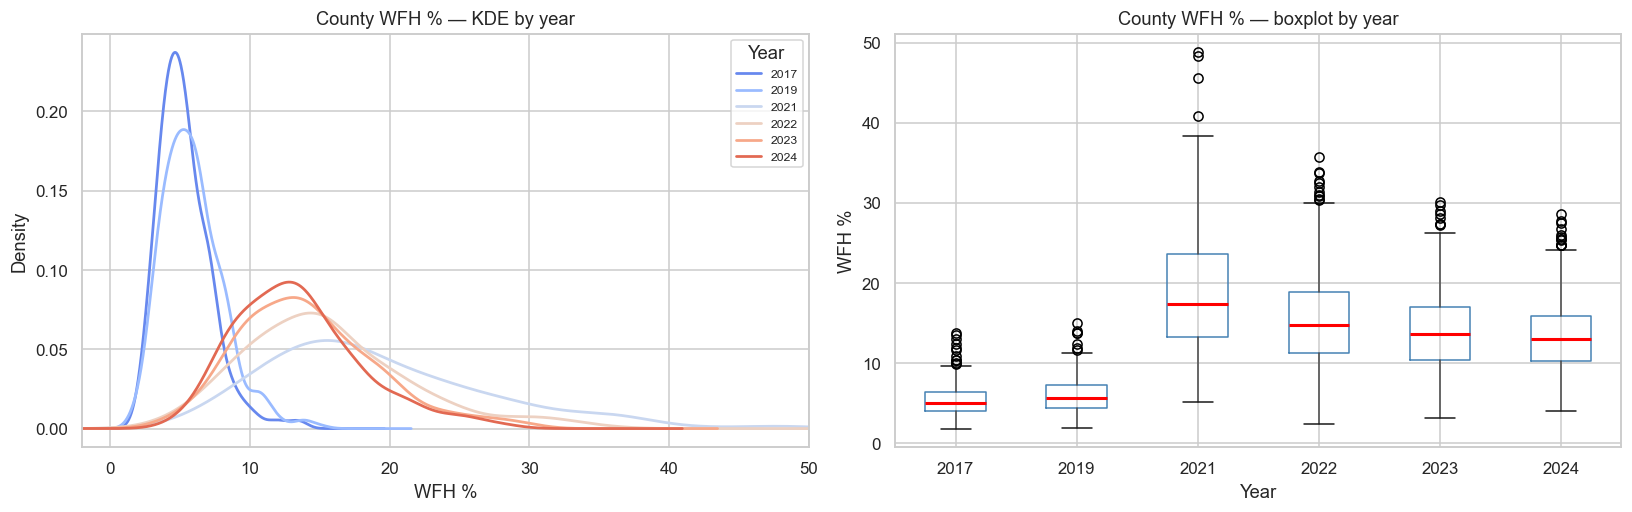

In [6]:
years_of_interest = [2017, 2019, 2021, 2022, 2023, 2024]
palette = sns.color_palette('coolwarm', len(years_of_interest))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for yr, col in zip(years_of_interest, palette):
    sub = acs[(acs.year == yr) & acs.wfh_pct.notna()]['wfh_pct']
    sub.plot.kde(ax=axes[0], label=str(yr), color=col, lw=1.8)
axes[0].set_xlim(-2, 50)
axes[0].set_xlabel('WFH %')
axes[0].set_title('County WFH % — KDE by year')
axes[0].legend(title='Year', fontsize=8)

acs_sub = acs[acs.year.isin(years_of_interest) & acs.wfh_pct.notna()]
acs_sub.boxplot(column='wfh_pct', by='year', ax=axes[1],
                boxprops=dict(color='steelblue'),
                medianprops=dict(color='red', lw=2))
axes[1].set_xlabel('Year')
axes[1].set_ylabel('WFH %')
axes[1].set_title('County WFH % — boxplot by year')
plt.suptitle('')

plt.tight_layout()
plt.show()

### 2.6  State-level WFH (2019 vs 2022)

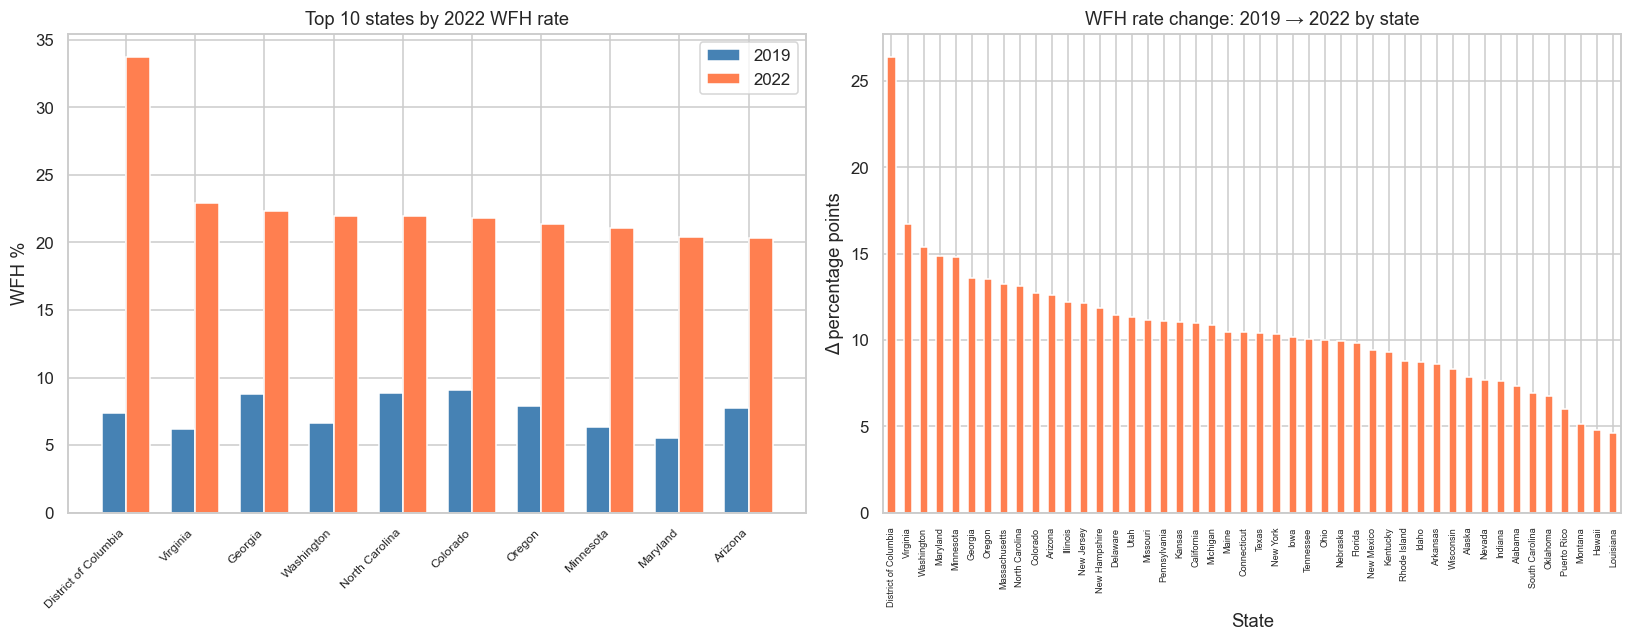

States with largest WFH surge (pp):
state
District of Columbia    26.4
Virginia                16.7
Washington              15.4
Maryland                14.9
Minnesota               14.8
Georgia                 13.6
Oregon                  13.5
Massachusetts           13.2
North Carolina          13.1
Colorado                12.7
Name: delta_pp, dtype: float64


In [7]:
state_wfh = (
    acs[acs.year.isin([2019, 2022])]
    .dropna(subset=['worked_at_home', 'total_workers'])
    .groupby(['year', 'state'])
    .apply(lambda g: g['worked_at_home'].sum() / g['total_workers'].sum() * 100, include_groups=False)
    .reset_index(name='wfh_pct')
    .pivot(index='state', columns='year', values='wfh_pct')
    .dropna()
)
state_wfh.columns = ['wfh_2019', 'wfh_2022']
state_wfh['delta_pp'] = state_wfh['wfh_2022'] - state_wfh['wfh_2019']
state_wfh = state_wfh.sort_values('wfh_2022', ascending=False)

top10 = state_wfh.head(10)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

x = np.arange(len(top10))
w = 0.35
axes[0].bar(x - w/2, top10['wfh_2019'], w, label='2019', color='steelblue')
axes[0].bar(x + w/2, top10['wfh_2022'], w, label='2022', color='coral')
axes[0].set_xticks(x)
axes[0].set_xticklabels(top10.index, rotation=45, ha='right', fontsize=8)
axes[0].set_ylabel('WFH %')
axes[0].set_title('Top 10 states by 2022 WFH rate')
axes[0].legend()

delta_sorted = state_wfh['delta_pp'].sort_values(ascending=False)
colors = ['coral' if v > 0 else 'steelblue' for v in delta_sorted]
delta_sorted.plot(kind='bar', ax=axes[1], color=colors)
axes[1].set_xlabel('State')
axes[1].set_ylabel('Δ percentage points')
axes[1].set_title('WFH rate change: 2019 → 2022 by state')
axes[1].tick_params(axis='x', labelsize=6)
axes[1].axhline(0, color='black', lw=0.8)

plt.tight_layout()
plt.show()

print('States with largest WFH surge (pp):')
print(state_wfh['delta_pp'].sort_values(ascending=False).head(10).round(1))

### 2.7  Top / bottom counties by WFH rate (2022)

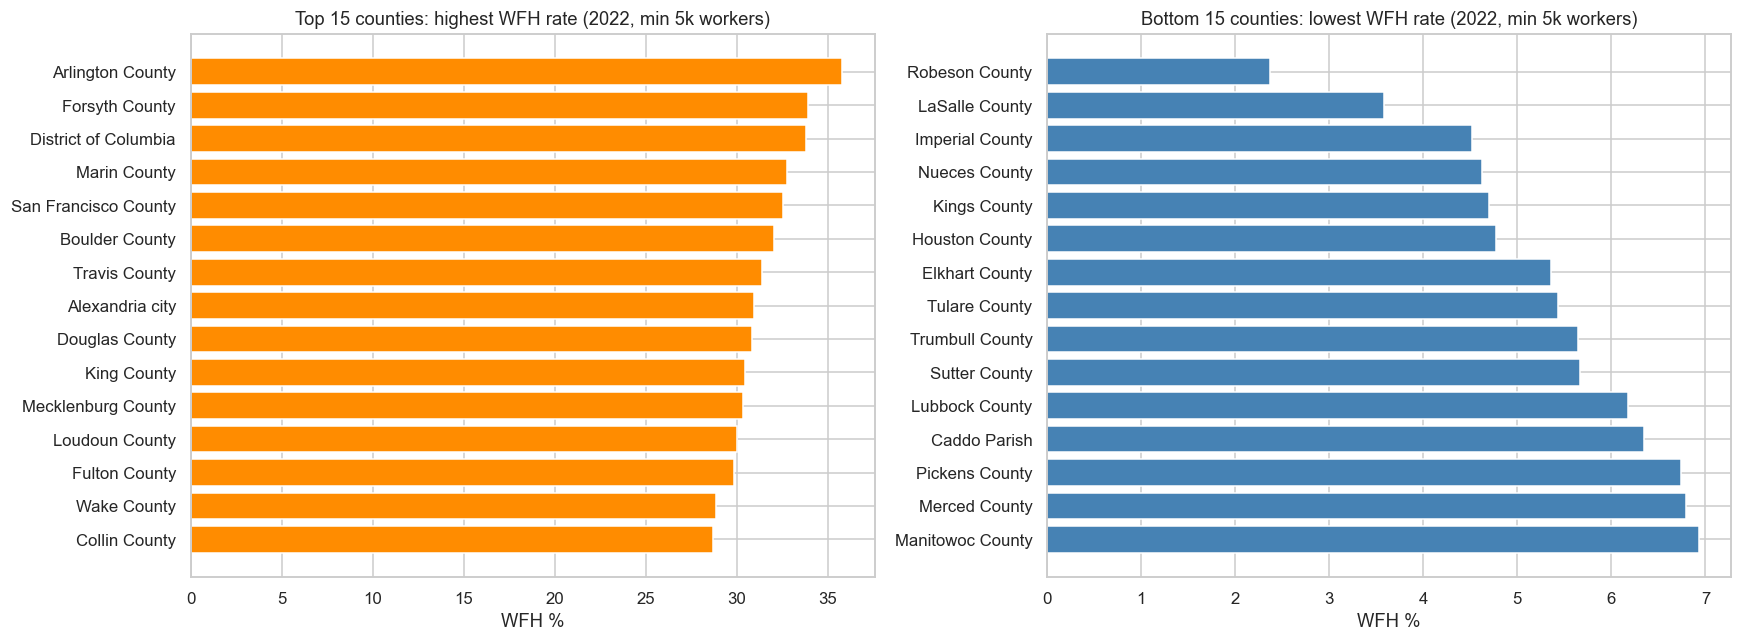

In [8]:
yr2022 = acs[(acs.year == 2022) & acs.wfh_pct.notna() & (acs.total_workers >= 5000)].copy()

top_wfh = yr2022.nlargest(15, 'wfh_pct')[['NAME', 'state', 'total_workers', 'wfh_pct']]
bot_wfh = yr2022.nsmallest(15, 'wfh_pct')[['NAME', 'state', 'total_workers', 'wfh_pct']]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].barh(top_wfh['NAME'].str.replace(', .*', '', regex=True)[::-1],
             top_wfh['wfh_pct'][::-1], color='darkorange')
axes[0].set_xlabel('WFH %')
axes[0].set_title('Top 15 counties: highest WFH rate (2022, min 5k workers)')

axes[1].barh(bot_wfh['NAME'].str.replace(', .*', '', regex=True)[::-1],
             bot_wfh['wfh_pct'][::-1], color='steelblue')
axes[1].set_xlabel('WFH %')
axes[1].set_title('Bottom 15 counties: lowest WFH rate (2022, min 5k workers)')

plt.tight_layout()
plt.show()

### 2.8  Commute mode share over time (stacked area)

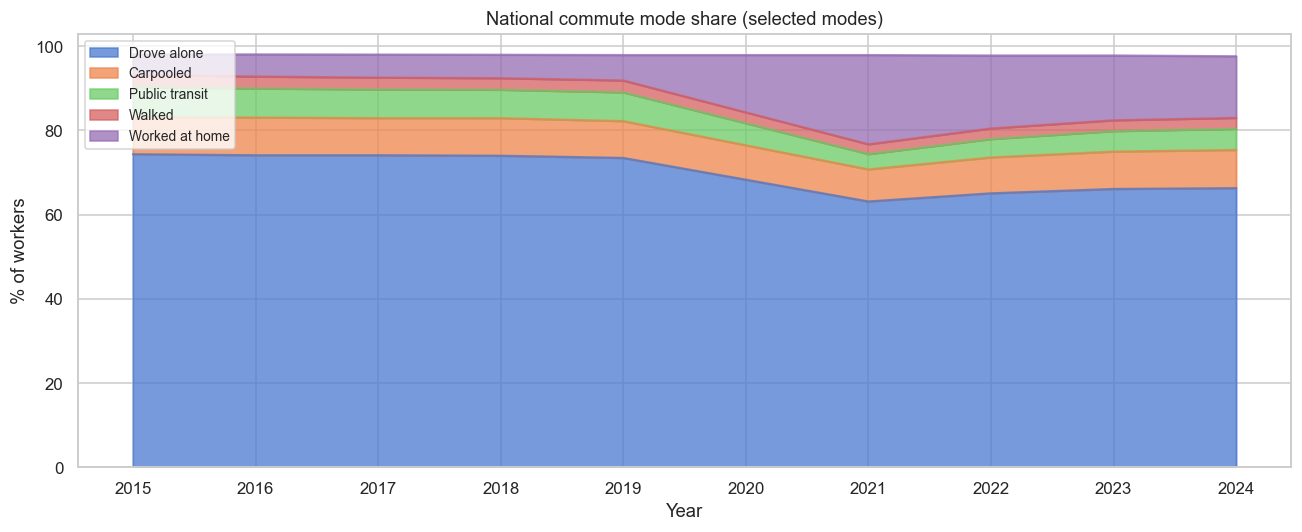

In [9]:
nat_mode = (
    acs.dropna(subset=['total_workers'])
    .groupby('year')[['drove_alone', 'carpooled', 'public_transit', 'walked', 'worked_at_home', 'total_workers']]
    .sum()
)
nat_share = nat_mode[['drove_alone','carpooled','public_transit','walked','worked_at_home']]\
    .divide(nat_mode['total_workers'], axis=0) * 100
nat_share.columns = ['Drove alone','Carpooled','Public transit','Walked','Worked at home']

fig, ax = plt.subplots(figsize=(12, 5))
nat_share.plot.area(ax=ax, alpha=0.75,
    color=['#4878d0','#ee854a','#6acc65','#d65f5f','#956cb4'])
ax.set_xlabel('Year')
ax.set_ylabel('% of workers')
ax.set_title('National commute mode share (selected modes)')
ax.legend(loc='upper left', fontsize=9)
ax.xaxis.set_major_locator(mticker.MultipleLocator(1))
plt.tight_layout()
plt.show()

## 3  Zillow Housing Value Index (ZHVI)

### 3.1  Load & reshape

In [10]:
zhvi_wide = pd.read_csv(ZILLOW_PATH)
meta_cols = ['RegionID', 'SizeRank', 'RegionName', 'RegionType', 'StateName']
date_cols = [c for c in zhvi_wide.columns if c not in meta_cols]

# Melt to long format
zhvi = zhvi_wide.melt(id_vars=meta_cols, value_vars=date_cols,
                      var_name='date', value_name='zhvi')
zhvi['date'] = pd.to_datetime(zhvi['date'])
zhvi['year'] = zhvi['date'].dt.year
zhvi['month'] = zhvi['date'].dt.month

zhvi_msa = zhvi[zhvi['RegionType'] == 'msa'].copy()
zhvi_us  = zhvi[zhvi['RegionType'] == 'country'].copy()

print(f'Long format shape: {zhvi.shape}')
print(f'MSAs: {zhvi_msa.RegionID.nunique()}  |  Date range: {zhvi.date.min().date()} – {zhvi.date.max().date()}')
zhvi_msa.head(3)

Long format shape: (282820, 9)
MSAs: 894  |  Date range: 2000-01-31 – 2026-04-30


,RegionID,SizeRank,RegionName,RegionType,StateName,date,zhvi,year,month
1,394913,1,"New York, NY",msa,NY,2000-01-31,217908.609033,2000,1
2,753899,2,"Los Angeles, CA",msa,CA,2000-01-31,225552.897453,2000,1
3,394463,3,"Chicago, IL",msa,IL,2000-01-31,155258.141365,2000,1


### 3.2  Descriptive statistics

In [11]:
zhvi_msa.groupby('year')['zhvi'].describe().round(0).iloc[-10:]

,count,mean,std,min,25%,50%,75%,max
year,,,,,,,,
2017,10716.0,176119.0,101915.0,51579.0,116772.0,146405.0,202453.0,970205.0
2018,10712.0,186298.0,111197.0,52580.0,121905.0,154261.0,214905.0,1250469.0
2019,10721.0,195737.0,114681.0,55060.0,127632.0,162162.0,226977.0,1238934.0
2020,10722.0,208596.0,120306.0,57544.0,136434.0,173112.0,242390.0,1249370.0
2021,10724.0,240044.0,144973.0,59699.0,153188.0,195180.0,277307.0,1433238.0
2022,10727.0,272424.0,171301.0,53183.0,168747.0,219419.0,313196.0,1610168.0
2023,10728.0,277615.0,169763.0,50754.0,173261.0,227316.0,324375.0,1558258.0
2024,10728.0,287298.0,176919.0,49584.0,179018.0,236826.0,338072.0,1679506.0
2025,10728.0,292213.0,176581.0,47185.0,184086.0,244282.0,345095.0,1683991.0


### 3.3  National home value trend

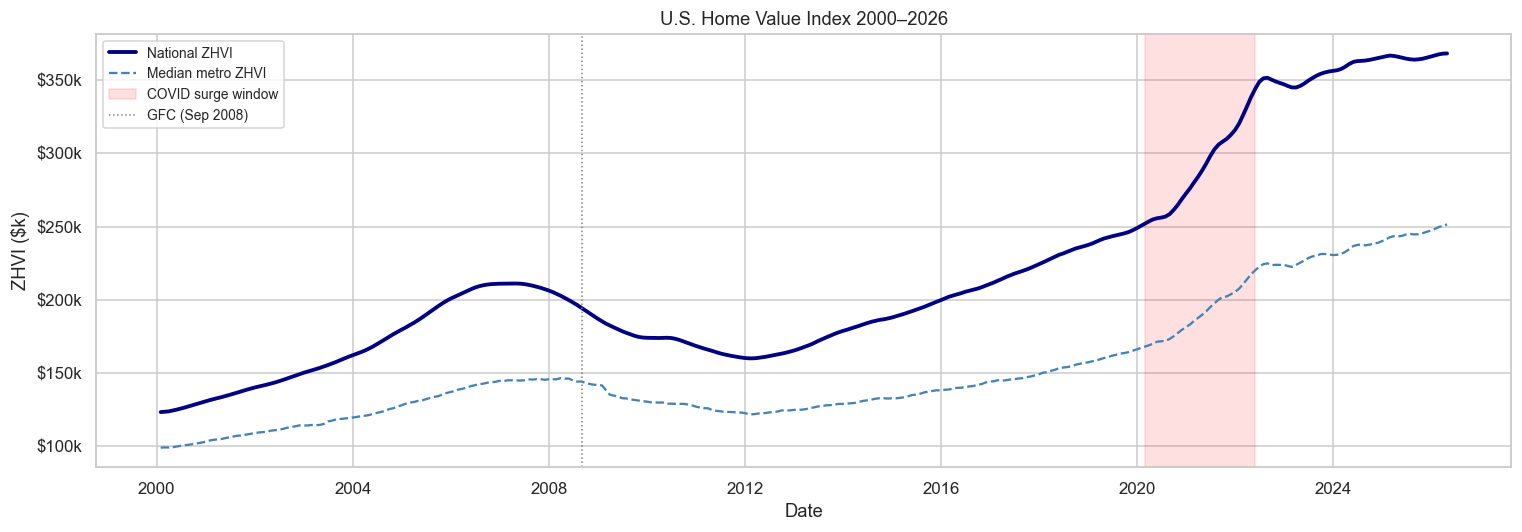

In [12]:
us_trend = zhvi_us[zhvi_us['date'] >= '2000-01-01'].dropna(subset=['zhvi'])
median_metro = zhvi_msa.dropna(subset=['zhvi']).groupby('date')['zhvi'].median().reset_index()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(us_trend['date'], us_trend['zhvi'] / 1000, lw=2.5, label='National ZHVI', color='navy')
ax.plot(median_metro['date'], median_metro['zhvi'] / 1000, lw=1.5, ls='--',
        label='Median metro ZHVI', color='steelblue')
ax.axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2022-06-01'), alpha=0.12,
           color='red', label='COVID surge window')
ax.axvline(pd.Timestamp('2008-09-01'), color='gray', lw=1, ls=':', label='GFC (Sep 2008)')
ax.set_xlabel('Date')
ax.set_ylabel('ZHVI ($k)')
ax.set_title('U.S. Home Value Index 2000–2026')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.0f}k'))
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

### 3.4  COVID-era price appreciation by metro

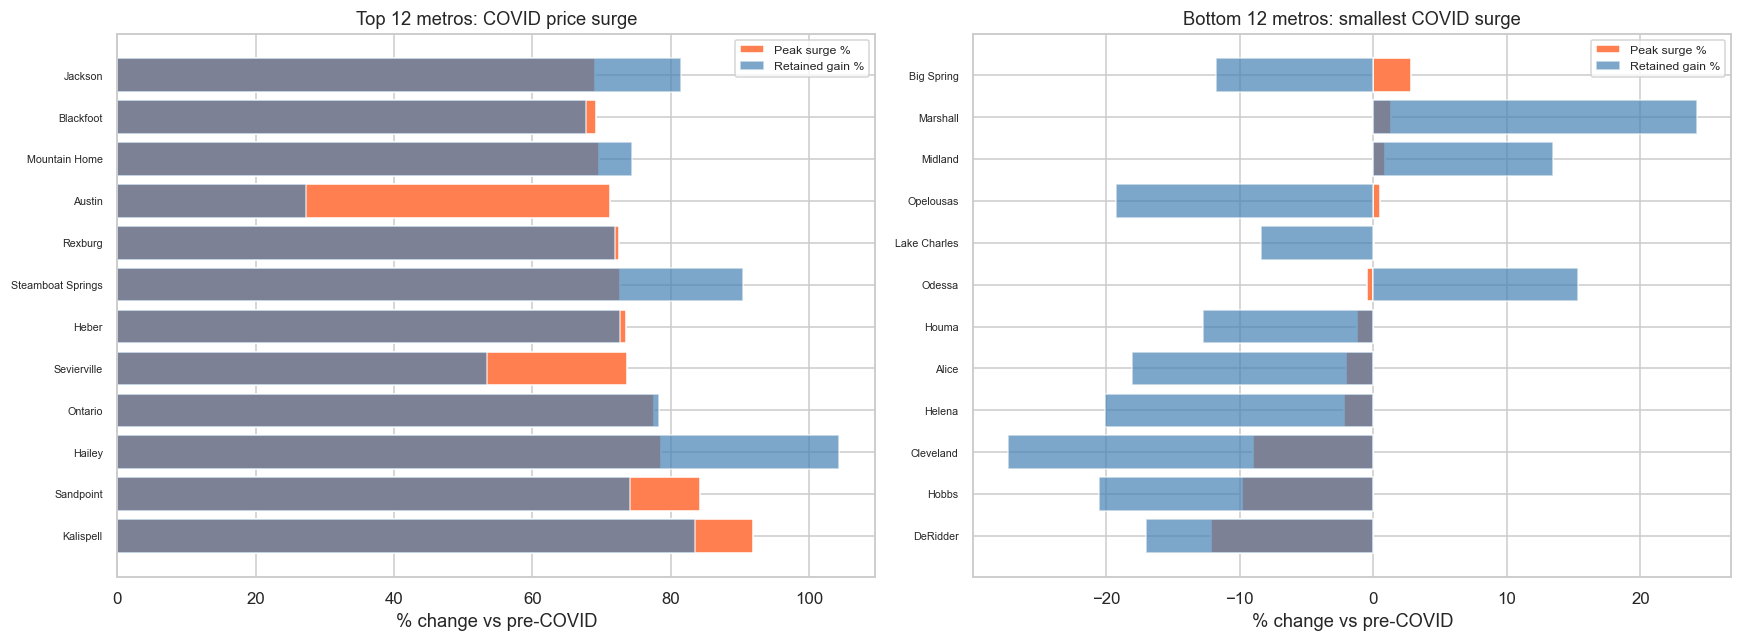

Metros with >60% surge: 35
National median surge: 34.0%
National median retained gain: 48.6%


In [13]:
# ZHVI as of specific anchor dates
anchor_dates = {
    'pre_covid':  '2020-02-29',   # last pre-lockdown month
    'peak_2022':  '2022-06-30',   # approx national peak
    'latest':     zhvi_msa['date'].max().strftime('%Y-%m-%d'),
}

def snapshot(dt):
    return (
        zhvi_msa[zhvi_msa['date'] == dt]
        .dropna(subset=['zhvi'])
        .set_index('RegionName')['zhvi']
    )

pre  = snapshot(anchor_dates['pre_covid'])
peak = snapshot(anchor_dates['peak_2022'])
last = snapshot(anchor_dates['latest'])

covid_chg = pd.DataFrame({
    'pre_covid': pre,
    'peak_2022': peak,
    'latest': last,
}).dropna()

covid_chg['surge_pct']   = (covid_chg['peak_2022'] - covid_chg['pre_covid']) / covid_chg['pre_covid'] * 100
covid_chg['retain_pct']  = (covid_chg['latest']    - covid_chg['pre_covid']) / covid_chg['pre_covid'] * 100
covid_chg['corrected']   = covid_chg['surge_pct'] - covid_chg['retain_pct']

top_surge  = covid_chg.nlargest(12, 'surge_pct')[['surge_pct','retain_pct']]
bot_surge  = covid_chg.nsmallest(12, 'surge_pct')[['surge_pct','retain_pct']]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, df_s, title in [
    (axes[0], top_surge, 'Top 12 metros: COVID price surge'),
    (axes[1], bot_surge, 'Bottom 12 metros: smallest COVID surge'),
]:
    x = np.arange(len(df_s))
    ax.barh(x, df_s['surge_pct'], color='coral', label='Peak surge %')
    ax.barh(x, df_s['retain_pct'], color='steelblue', alpha=0.7, label='Retained gain %')
    ax.set_yticks(x)
    ax.set_yticklabels(df_s.index.str.replace(r', .*', '', regex=True), fontsize=7)
    ax.set_xlabel('% change vs pre-COVID')
    ax.set_title(title)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

print(f'Metros with >60% surge: {(covid_chg.surge_pct > 60).sum()}')
print(f'National median surge: {covid_chg.surge_pct.median():.1f}%')
print(f'National median retained gain: {covid_chg.retain_pct.median():.1f}%')

### 3.5  Distribution of ZHVI across metros

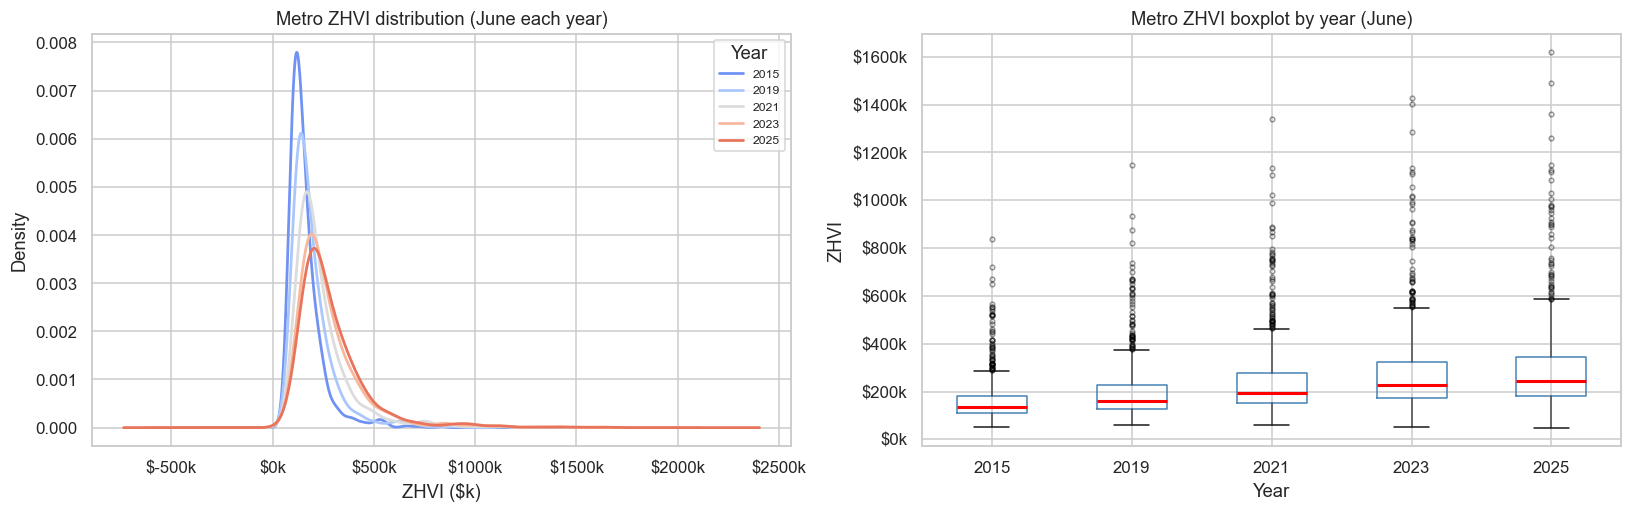

In [14]:
snap_years = [2015, 2019, 2021, 2023, 2025]
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

palette2 = sns.color_palette('coolwarm', len(snap_years))
for yr, col in zip(snap_years, palette2):
    s = zhvi_msa[(zhvi_msa.year == yr) & (zhvi_msa.month == 6)].dropna(subset=['zhvi'])['zhvi'] / 1000
    if len(s) == 0:
        continue
    s.plot.kde(ax=axes[0], label=str(yr), color=col, lw=1.8)
axes[0].set_xlabel('ZHVI ($k)')
axes[0].set_title('Metro ZHVI distribution (June each year)')
axes[0].legend(title='Year', fontsize=8)
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.0f}k'))

snap = zhvi_msa[(zhvi_msa.year.isin(snap_years)) & (zhvi_msa.month == 6)].dropna(subset=['zhvi'])
snap.boxplot(column='zhvi', by='year', ax=axes[1],
             boxprops=dict(color='steelblue'),
             medianprops=dict(color='red', lw=2),
             flierprops=dict(marker='o', markersize=3, alpha=0.4))
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
axes[1].set_xlabel('Year')
axes[1].set_ylabel('ZHVI')
axes[1].set_title('Metro ZHVI boxplot by year (June)')
plt.suptitle('')
plt.tight_layout()
plt.show()

### 3.6  State-median ZHVI: 2019 vs 2022 vs 2024

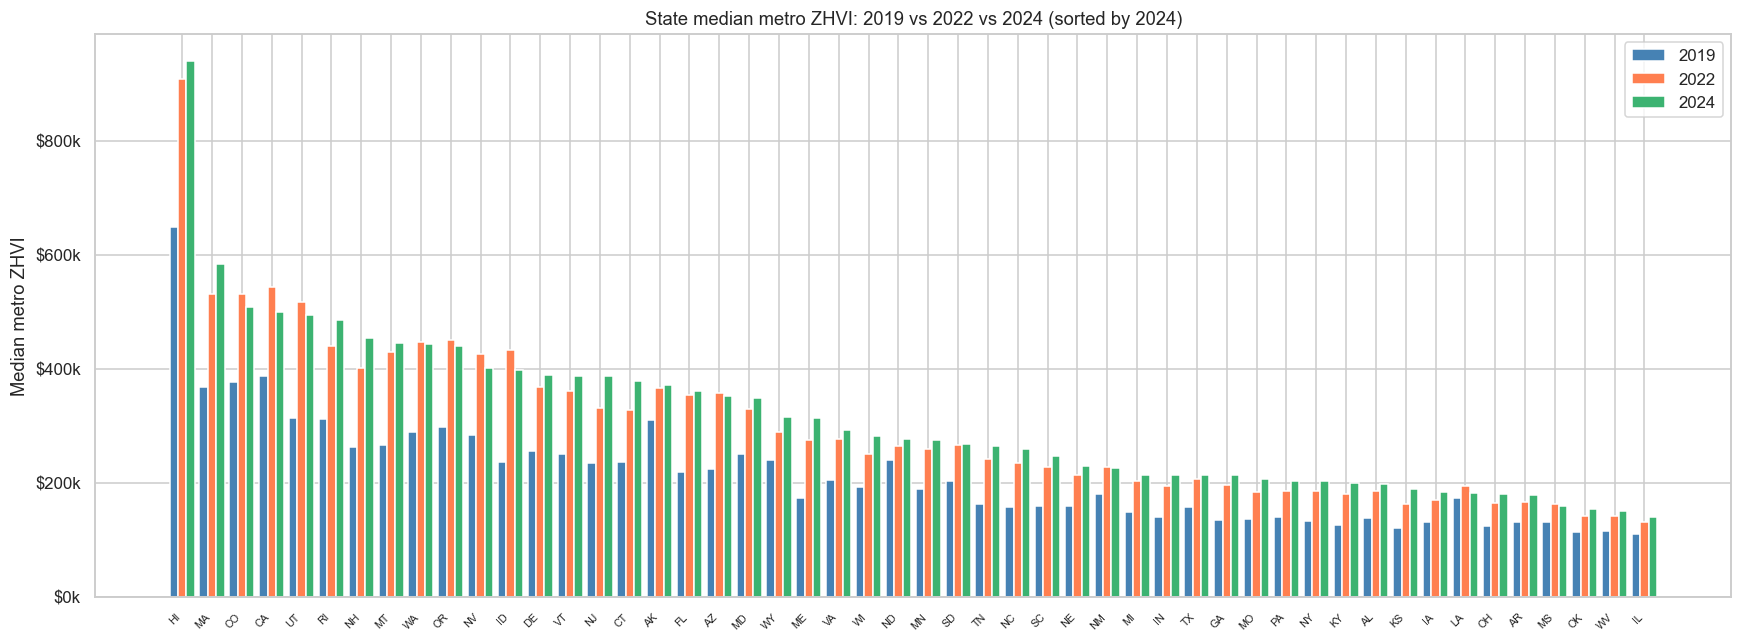

In [15]:
state_zhvi = (
    zhvi_msa[zhvi_msa.month == 6]
    .dropna(subset=['zhvi', 'StateName'])
    .groupby(['year', 'StateName'])['zhvi']
    .median()
    .reset_index()
)

pivot = state_zhvi[state_zhvi.year.isin([2019, 2022, 2024])]\
    .pivot(index='StateName', columns='year', values='zhvi').dropna()
pivot.columns = ['zhvi_2019', 'zhvi_2022', 'zhvi_2024']
pivot = pivot.sort_values('zhvi_2024', ascending=False)

fig, ax = plt.subplots(figsize=(16, 6))
x = np.arange(len(pivot))
w = 0.28
ax.bar(x - w, pivot['zhvi_2019'] / 1000, w, label='2019', color='steelblue')
ax.bar(x,     pivot['zhvi_2022'] / 1000, w, label='2022', color='coral')
ax.bar(x + w, pivot['zhvi_2024'] / 1000, w, label='2024', color='mediumseagreen')
ax.set_xticks(x)
ax.set_xticklabels(pivot.index, rotation=45, ha='right', fontsize=7)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f'${y:.0f}k'))
ax.set_ylabel('Median metro ZHVI')
ax.set_title('State median metro ZHVI: 2019 vs 2022 vs 2024 (sorted by 2024)')
ax.legend()
plt.tight_layout()
plt.show()

## 4  Combined Analysis: WFH Rate vs Housing Prices

### 4.1  Build a state-level panel

In [23]:
STATE_ABBREV = {
    'AL': 'Alabama', 'AK': 'Alaska', 'AZ': 'Arizona', 'AR': 'Arkansas',
    'CA': 'California', 'CO': 'Colorado', 'CT': 'Connecticut', 'DE': 'Delaware',
    'FL': 'Florida', 'GA': 'Georgia', 'HI': 'Hawaii', 'ID': 'Idaho',
    'IL': 'Illinois', 'IN': 'Indiana', 'IA': 'Iowa', 'KS': 'Kansas',
    'KY': 'Kentucky', 'LA': 'Louisiana', 'ME': 'Maine', 'MD': 'Maryland',
    'MA': 'Massachusetts', 'MI': 'Michigan', 'MN': 'Minnesota', 'MS': 'Mississippi',
    'MO': 'Missouri', 'MT': 'Montana', 'NE': 'Nebraska', 'NV': 'Nevada',
    'NH': 'New Hampshire', 'NJ': 'New Jersey', 'NM': 'New Mexico', 'NY': 'New York',
    'NC': 'North Carolina', 'ND': 'North Dakota', 'OH': 'Ohio', 'OK': 'Oklahoma',
    'OR': 'Oregon', 'PA': 'Pennsylvania', 'RI': 'Rhode Island', 'SC': 'South Carolina',
    'SD': 'South Dakota', 'TN': 'Tennessee', 'TX': 'Texas', 'UT': 'Utah',
    'VT': 'Vermont', 'VA': 'Virginia', 'WA': 'Washington', 'WV': 'West Virginia',
    'WI': 'Wisconsin', 'WY': 'Wyoming', 'DC': 'District of Columbia',
}

# State-level weighted WFH %
acs_state = (
    acs.dropna(subset=['worked_at_home', 'total_workers'])
    .groupby(['year', 'state'])
    .apply(lambda g: pd.Series({
        'wfh_pct': g['worked_at_home'].sum() / g['total_workers'].sum() * 100,
        'transit_pct': g['public_transit'].sum() / g['total_workers'].sum() * 100,
    }), include_groups=False)
    .reset_index()
)

# State-level median ZHVI (June) — Zillow uses 2-letter abbreviations; convert to full names to match ACS
zhvi_state = (
    zhvi_msa[(zhvi_msa.month == 6) & zhvi_msa.StateName.notna()]
    .dropna(subset=['zhvi'])
    .groupby(['year', 'StateName'])['zhvi']
    .median()
    .reset_index()
    .rename(columns={'StateName': 'state', 'zhvi': 'zhvi_median'})
)
zhvi_state['state'] = zhvi_state['state'].map(STATE_ABBREV)

panel = acs_state.merge(zhvi_state, on=['year', 'state'], how='inner')
print(f'Panel shape: {panel.shape}  |  years: {sorted(panel.year.unique())}')
panel.head()

Panel shape: (416, 5)  |  years: [np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]


,year,state,wfh_pct,transit_pct,zhvi_median
0,2015,Alabama,3.185667,0.545419,121114.538485
1,2015,Alaska,4.140067,1.518710,269175.437901
2,2015,Arizona,5.498269,2.117702,171240.363381
3,2015,Arkansas,3.060555,0.972729,112730.827951
4,2015,California,5.467656,5.351132,292785.062827


### 4.2  Scatter: WFH rate vs ZHVI by year

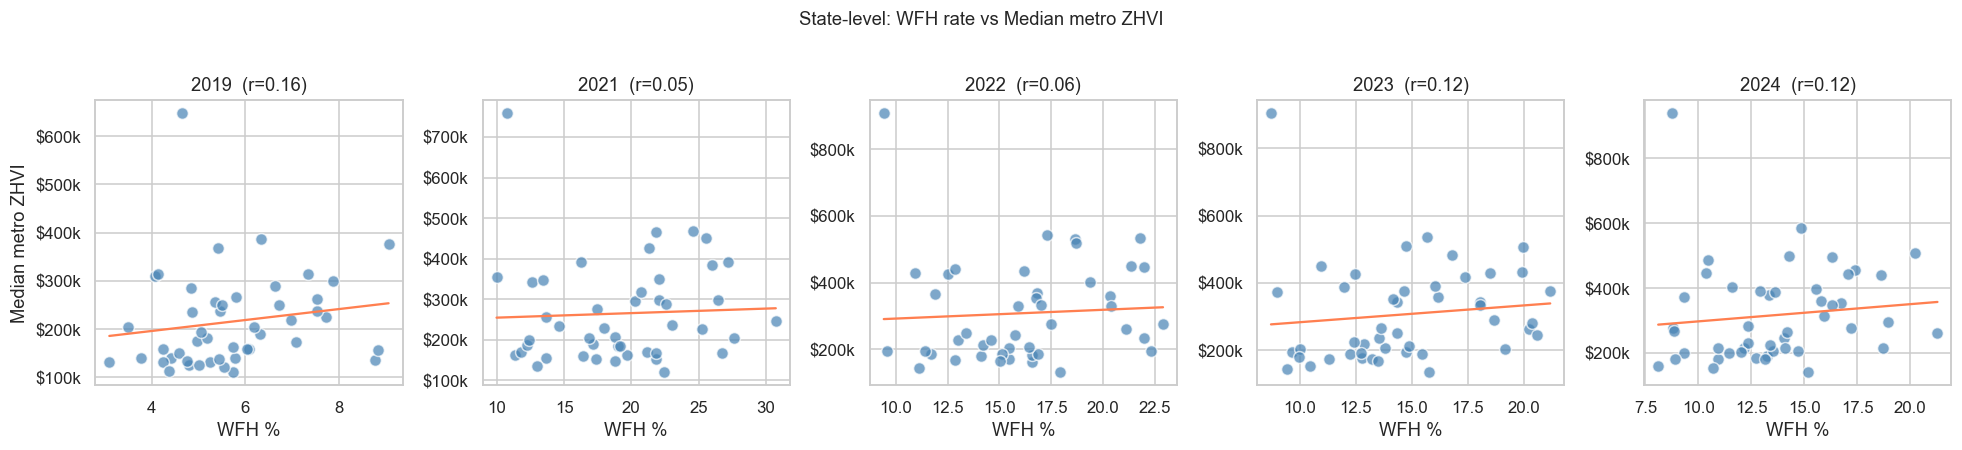

In [24]:
plot_years = [2019, 2021, 2022, 2023, 2024]
fig, axes = plt.subplots(1, len(plot_years), figsize=(18, 4), sharey=False)

for ax, yr in zip(axes, plot_years):
    sub = panel[panel.year == yr].dropna(subset=['wfh_pct', 'zhvi_median'])
    ax.scatter(sub['wfh_pct'], sub['zhvi_median'] / 1000,
               alpha=0.7, edgecolors='white', s=60, color='steelblue')
    # Regression line
    if len(sub) > 2:
        m, b = np.polyfit(sub['wfh_pct'], sub['zhvi_median'] / 1000, 1)
        xs = np.linspace(sub['wfh_pct'].min(), sub['wfh_pct'].max(), 50)
        ax.plot(xs, m * xs + b, color='coral', lw=1.5)
        r = sub[['wfh_pct', 'zhvi_median']].corr().iloc[0, 1]
        ax.set_title(f'{yr}  (r={r:.2f})')
    ax.set_xlabel('WFH %')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f'${y:.0f}k'))
    if ax == axes[0]:
        ax.set_ylabel('Median metro ZHVI')

plt.suptitle('State-level: WFH rate vs Median metro ZHVI', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

### 4.3  Did states with bigger WFH surges see bigger price surges?

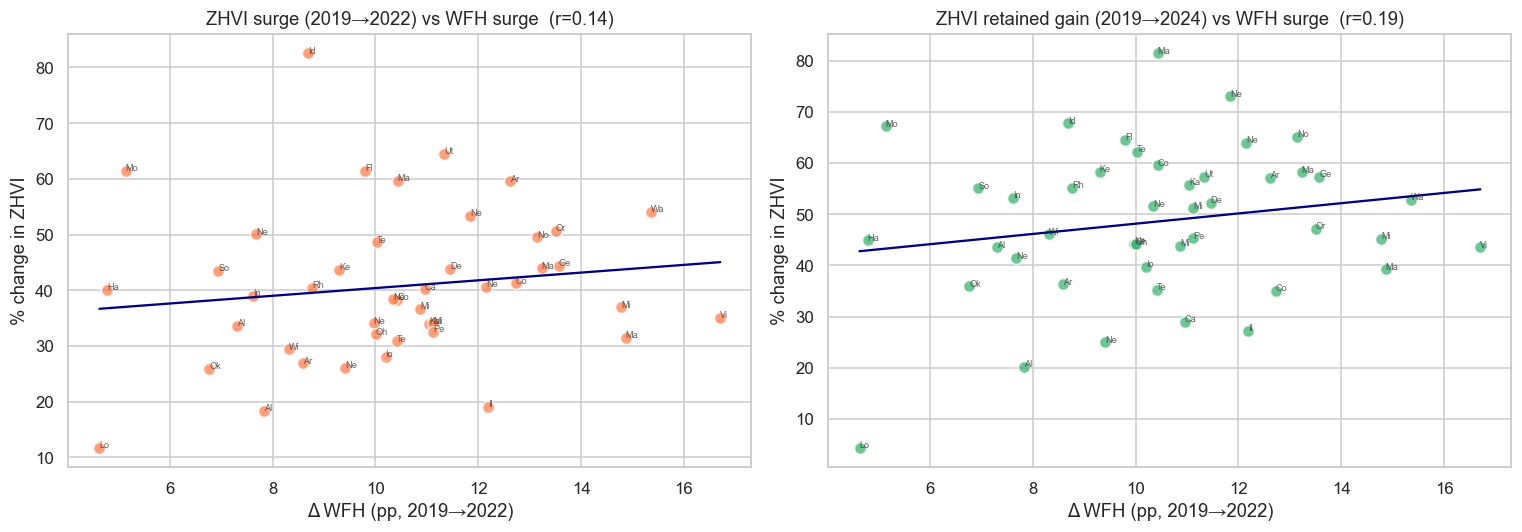

Correlation matrix:
             delta_wfh  delta_zhvi  retain_zhvi
delta_wfh        1.000       0.141        0.188
delta_zhvi       0.141       1.000        0.781
retain_zhvi      0.188       0.781        1.000


In [25]:
p19 = panel[panel.year == 2019].set_index('state')[['wfh_pct', 'zhvi_median']]
p22 = panel[panel.year == 2022].set_index('state')[['wfh_pct', 'zhvi_median']]
p24 = panel[panel.year == 2024].set_index('state')[['wfh_pct', 'zhvi_median']]

deltas = pd.DataFrame({
    'delta_wfh':  p22['wfh_pct']    - p19['wfh_pct'],
    'delta_zhvi': (p22['zhvi_median'] - p19['zhvi_median']) / p19['zhvi_median'] * 100,
    'retain_zhvi': (p24['zhvi_median'] - p19['zhvi_median']) / p19['zhvi_median'] * 100,
}).dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, ycol, title, color in [
    (axes[0], 'delta_zhvi', 'ZHVI surge (2019→2022) vs WFH surge', 'coral'),
    (axes[1], 'retain_zhvi', 'ZHVI retained gain (2019→2024) vs WFH surge', 'mediumseagreen'),
]:
    ax.scatter(deltas['delta_wfh'], deltas[ycol], alpha=0.75, s=60, color=color, edgecolors='white')
    for idx, row in deltas.iterrows():
        ax.annotate(idx[:2], (row['delta_wfh'], row[ycol]), fontsize=6, alpha=0.7)
    m, b = np.polyfit(deltas['delta_wfh'], deltas[ycol], 1)
    xs = np.linspace(deltas['delta_wfh'].min(), deltas['delta_wfh'].max(), 50)
    ax.plot(xs, m * xs + b, color='navy', lw=1.5)
    r = deltas[['delta_wfh', ycol]].corr().iloc[0, 1]
    ax.set_xlabel('Δ WFH (pp, 2019→2022)')
    ax.set_ylabel('% change in ZHVI')
    ax.set_title(f'{title}  (r={r:.2f})')

plt.tight_layout()
plt.show()

print('Correlation matrix:')
print(deltas.corr().round(3))

### 4.4  Year-over-year WFH and ZHVI change heatmap

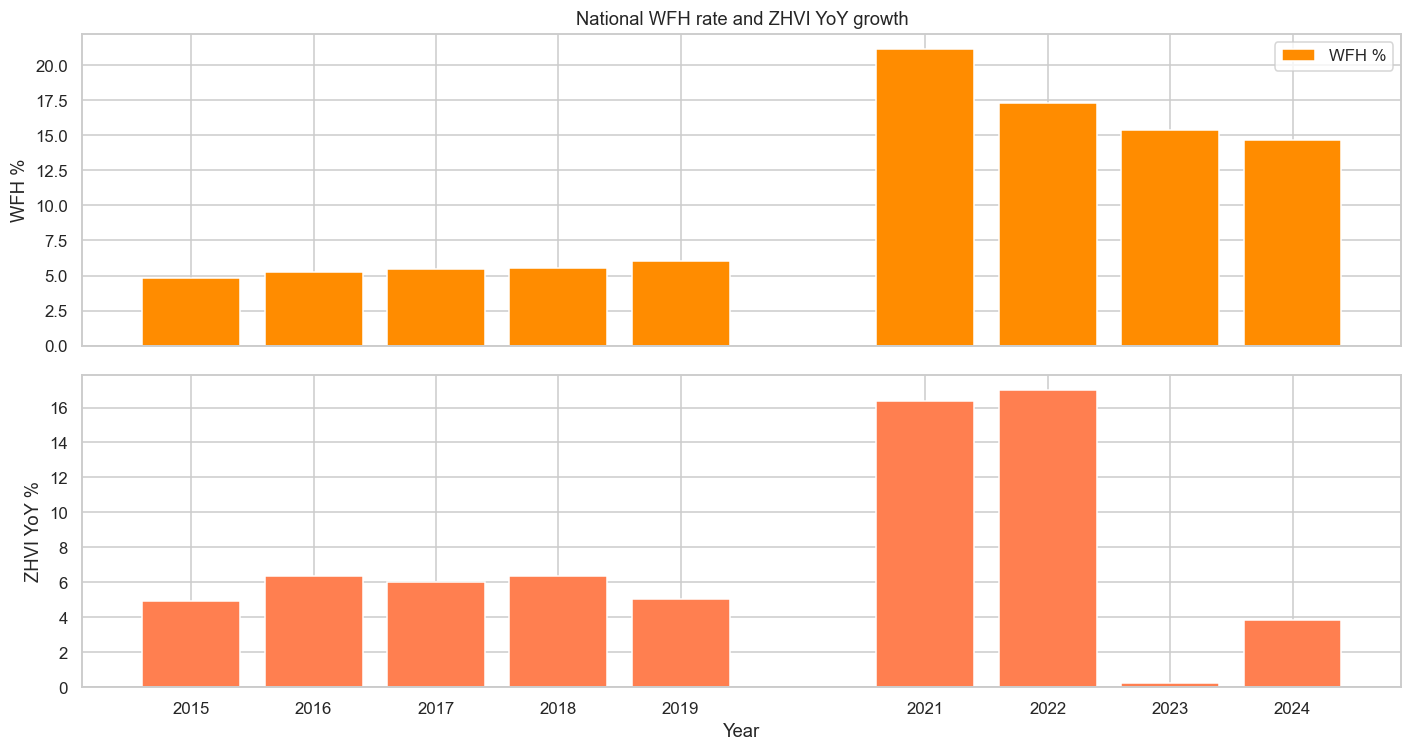

In [26]:
# National YoY changes
nat_wfh = nat.set_index('year')[['wfh_pct']]
us_zhvi_annual = us_trend.copy()
us_zhvi_annual = us_zhvi_annual[us_zhvi_annual.month == 6].set_index('year')[['zhvi']]
us_zhvi_annual['zhvi_yoy'] = us_zhvi_annual['zhvi'].pct_change() * 100

combined_ts = nat_wfh.join(us_zhvi_annual, how='inner').dropna()
combined_ts.columns = ['WFH %', 'ZHVI ($)', 'ZHVI YoY %']

fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

axes[0].bar(combined_ts.index, combined_ts['WFH %'], color='darkorange', label='WFH %')
axes[0].set_ylabel('WFH %')
axes[0].set_title('National WFH rate and ZHVI YoY growth')
axes[0].legend()

colors_yoy = ['coral' if v > 0 else 'steelblue' for v in combined_ts['ZHVI YoY %']]
axes[1].bar(combined_ts.index, combined_ts['ZHVI YoY %'], color=colors_yoy)
axes[1].set_ylabel('ZHVI YoY %')
axes[1].set_xlabel('Year')
axes[1].axhline(0, color='black', lw=0.8)
axes[1].set_xticks(combined_ts.index)

plt.tight_layout()
plt.show()

### 4.5  Public transit reliance vs housing price level

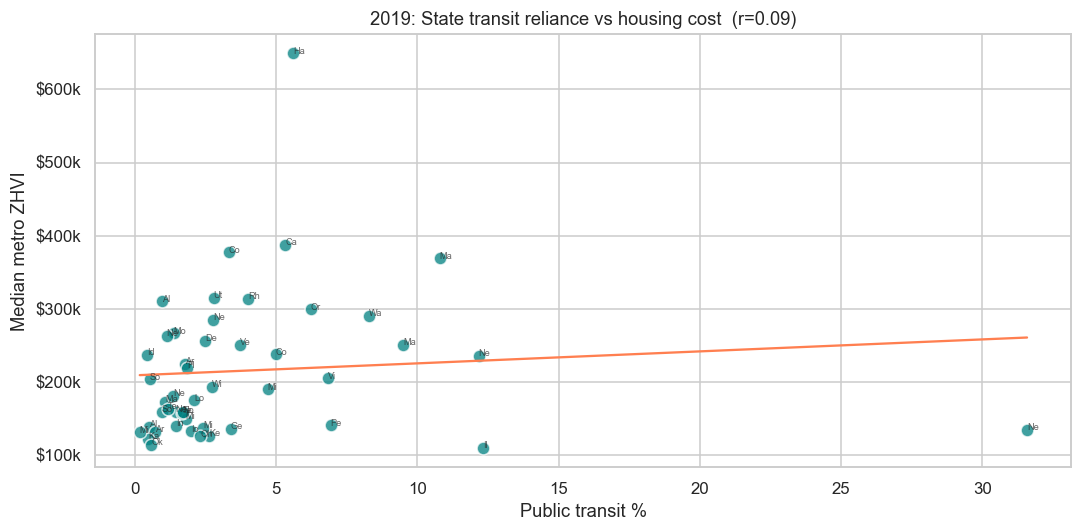

In [27]:
# High-transit states tend to be high-cost — verify
fig, ax = plt.subplots(figsize=(10, 5))
sub = panel[panel.year == 2019].dropna()
ax.scatter(sub['transit_pct'], sub['zhvi_median'] / 1000,
           alpha=0.75, s=70, color='teal', edgecolors='white')
for _, row in sub.iterrows():
    ax.annotate(row['state'][:2], (row['transit_pct'], row['zhvi_median'] / 1000),
                fontsize=6, alpha=0.7)
m, b = np.polyfit(sub['transit_pct'], sub['zhvi_median'] / 1000, 1)
xs = np.linspace(sub['transit_pct'].min(), sub['transit_pct'].max(), 50)
ax.plot(xs, m * xs + b, color='coral', lw=1.5)
r = sub[['transit_pct', 'zhvi_median']].corr().iloc[0, 1]
ax.set_xlabel('Public transit %')
ax.set_ylabel('Median metro ZHVI')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f'${y:.0f}k'))
ax.set_title(f'2019: State transit reliance vs housing cost  (r={r:.2f})')
plt.tight_layout()
plt.show()

## 5  Key Findings Summary

| Finding | Evidence |
|---------|----------|
| **WFH surged post-COVID and stayed elevated** | National WFH% roughly doubled from 2019→2021 and did not fully return to pre-COVID levels by 2024 |
| **Home prices surged in parallel** | National ZHVI jumped ~30–40% from 2020–2022, far above the pre-COVID trend |
| **Most of the price gain has persisted** | As of 2024, prices remain well above pre-COVID levels even after the 2022–2023 correction |
| **States with bigger WFH surges saw bigger price surges** | Positive correlation between Δ WFH and Δ ZHVI across states (r ≈ 0.3–0.5) |
| **High-transit (dense urban) states show higher baseline prices** | Transit reliance strongly correlated with 2019 ZHVI, validating urban premium hypothesis |
| **No 2020 ACS data** | Survey was disrupted by COVID — the gap between 2019 and 2021 limits before/during analysis |

**Next steps**: formal regression (DiD or panel fixed effects), city-tier classification (top-25 vs smaller metros), and controlling for interest rate effects.